In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")

# Load data mentah
df = pd.read_csv("../data/raw/weather_toba_2015_2024.csv", parse_dates=["date"])
df = df.sort_values(["location", "date"]).reset_index(drop=True)

print(f"Data loaded: {len(df):,} baris, {df['location'].nunique()} lokasi")
df.head(3)

Data loaded: 18,265 baris, 5 lokasi


,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,windspeed_10m_max,winddirection_10m_dominant,weathercode,et0_fao_evapotranspiration,date,location,lat,lon
0,28.3,27.3,27.8,0.0,7.4,79,3,4.75,2015-01-01,Balige (Tobasa),-2.3333,99.0667
1,28.2,27.4,27.8,0.0,8.2,246,3,4.77,2015-01-02,Balige (Tobasa),-2.3333,99.0667
2,28.0,26.3,27.3,3.3,22.0,298,55,4.27,2015-01-03,Balige (Tobasa),-2.3333,99.0667


In [2]:
def add_temporal_features(df):
    df = df.copy()
    df["day_of_week"]   = df["date"].dt.dayofweek        # 0=Senin, 6=Minggu
    df["day_of_year"]   = df["date"].dt.dayofyear         # 1–365
    df["month"]         = df["date"].dt.month
    df["year"]          = df["date"].dt.year
    df["week_of_year"]  = df["date"].dt.isocalendar().week.astype(int)
    df["is_weekend"]    = df["day_of_week"].isin([5, 6]).astype(int)

    # Encode siklus musiman dengan sin/cos agar model tahu Jan & Des itu berdekatan
    df["month_sin"]     = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"]     = np.cos(2 * np.pi * df["month"] / 12)
    df["day_sin"]       = np.sin(2 * np.pi * df["day_of_year"] / 365)
    df["day_cos"]       = np.cos(2 * np.pi * df["day_of_year"] / 365)

    # Musim hujan kawasan Toba: November–Maret
    df["is_rainy_season"] = df["month"].isin([11, 12, 1, 2, 3]).astype(int)

    return df

df = add_temporal_features(df)
print("Fitur temporal ditambahkan:")
temporal_cols = ["day_of_week","day_of_year","month","week_of_year",
                 "is_weekend","month_sin","month_cos","is_rainy_season"]
print(df[["date"] + temporal_cols].head(3).to_string(index=False))

Fitur temporal ditambahkan:
      date  day_of_week  day_of_year  month  week_of_year  is_weekend  month_sin  month_cos  is_rainy_season
2015-01-01            3            1      1             1           0        0.5   0.866025                1
2015-01-02            4            2      1             1           0        0.5   0.866025                1
2015-01-03            5            3      1             1           1        0.5   0.866025                1


In [3]:
def add_lag_features(df):
    df = df.copy()

    # Proses per lokasi agar lag tidak bocor antar lokasi
    dfs = []
    for loc in df["location"].unique():
        subset = df[df["location"] == loc].copy().sort_values("date")

        # Lag suhu maksimum
        for lag in [1, 2, 3, 7, 14]:
            subset[f"temp_max_lag_{lag}"] = subset["temperature_2m_max"].shift(lag)

        # Lag curah hujan
        for lag in [1, 2, 3, 7]:
            subset[f"precip_lag_{lag}"] = subset["precipitation_sum"].shift(lag)

        # Lag angin
        for lag in [1, 3]:
            subset[f"wind_lag_{lag}"] = subset["windspeed_10m_max"].shift(lag)

        dfs.append(subset)

    return pd.concat(dfs, ignore_index=True).sort_values(["location","date"]).reset_index(drop=True)

df = add_lag_features(df)
lag_cols = [c for c in df.columns if "lag" in c]
print(f"Fitur lag ditambahkan: {len(lag_cols)} kolom")
print(lag_cols)

Fitur lag ditambahkan: 11 kolom
['temp_max_lag_1', 'temp_max_lag_2', 'temp_max_lag_3', 'temp_max_lag_7', 'temp_max_lag_14', 'precip_lag_1', 'precip_lag_2', 'precip_lag_3', 'precip_lag_7', 'wind_lag_1', 'wind_lag_3']


In [4]:
def add_rolling_features(df):
    df = df.copy()
    dfs = []

    for loc in df["location"].unique():
        subset = df[df["location"] == loc].copy().sort_values("date")

        # Rolling suhu
        for window in [7, 14, 30]:
            subset[f"temp_max_roll_{window}d"]  = subset["temperature_2m_max"].rolling(window).mean()
            subset[f"temp_min_roll_{window}d"]  = subset["temperature_2m_min"].rolling(window).mean()

        # Rolling curah hujan
        for window in [7, 14, 30]:
            subset[f"precip_roll_{window}d"]    = subset["precipitation_sum"].rolling(window).mean()
            subset[f"precip_sum_{window}d"]     = subset["precipitation_sum"].rolling(window).sum()

        # Rolling angin
        subset["wind_roll_7d"]  = subset["windspeed_10m_max"].rolling(7).mean()
        subset["wind_roll_30d"] = subset["windspeed_10m_max"].rolling(30).mean()

        # Volatilitas suhu (std 7 hari) — indikator cuaca tidak stabil
        subset["temp_std_7d"]   = subset["temperature_2m_mean"].rolling(7).std()

        dfs.append(subset)

    return pd.concat(dfs, ignore_index=True).sort_values(["location","date"]).reset_index(drop=True)

df = add_rolling_features(df)
roll_cols = [c for c in df.columns if "roll" in c or "std" in c or "sum_" in c]
print(f"Fitur rolling ditambahkan: {len(roll_cols)} kolom")
print(roll_cols)

Fitur rolling ditambahkan: 15 kolom
['temp_max_roll_7d', 'temp_min_roll_7d', 'temp_max_roll_14d', 'temp_min_roll_14d', 'temp_max_roll_30d', 'temp_min_roll_30d', 'precip_roll_7d', 'precip_sum_7d', 'precip_roll_14d', 'precip_sum_14d', 'precip_roll_30d', 'precip_sum_30d', 'wind_roll_7d', 'wind_roll_30d', 'temp_std_7d']


In [5]:
def add_warning_labels(df):
    df = df.copy()

    # Label risiko curah hujan
    df["rain_label"] = pd.cut(
        df["precipitation_sum"],
        bins=[-1, 10, 50, 100, float("inf")],
        labels=["normal", "sedang", "lebat", "sangat_lebat"]
    )

    # Label risiko angin
    df["wind_warning"] = (df["windspeed_10m_max"] > 40).astype(int)

    # Label risiko kombinasi (hujan lebat ATAU angin kencang)
    df["high_risk"] = (
        (df["precipitation_sum"] > 50) | (df["windspeed_10m_max"] > 40)
    ).astype(int)

    return df

df = add_warning_labels(df)

print("Distribusi label risiko curah hujan:")
print(df["rain_label"].value_counts())
print(f"\nHari angin bahaya  : {df['wind_warning'].sum()}")
print(f"Hari risiko tinggi : {df['high_risk'].sum()}")

Distribusi label risiko curah hujan:
rain_label
normal          12413
sedang           5636
lebat             163
sangat_lebat       53
Name: count, dtype: int64

Hari angin bahaya  : 177
Hari risiko tinggi : 372


In [6]:
# Berapa baris sebelum drop
before = len(df)

# Drop baris yang punya NaN di fitur lag/rolling
feature_cols = [c for c in df.columns if any(x in c for x in ["lag","roll","std","sum_"])]
df_clean = df.dropna(subset=feature_cols).reset_index(drop=True)

after = len(df_clean)
print(f"Baris sebelum drop NaN : {before:,}")
print(f"Baris setelah drop NaN : {after:,}")
print(f"Baris dihapus          : {before - after:,} (wajar, dari window lag/rolling)")

# Simpan
output_path = "../data/processed/features_toba.csv"
df_clean.to_csv(output_path, index=False)

print(f"\nData tersimpan: {output_path}")
print(f"Total fitur    : {len(df_clean.columns)} kolom")
print(f"Total baris    : {len(df_clean):,}")

Baris sebelum drop NaN : 18,265
Baris setelah drop NaN : 18,120
Baris dihapus          : 145 (wajar, dari window lag/rolling)

Data tersimpan: ../data/processed/features_toba.csv
Total fitur    : 52 kolom
Total baris    : 18,120


Type corr: <class 'pandas.core.series.Series'>
Shape: (45,)


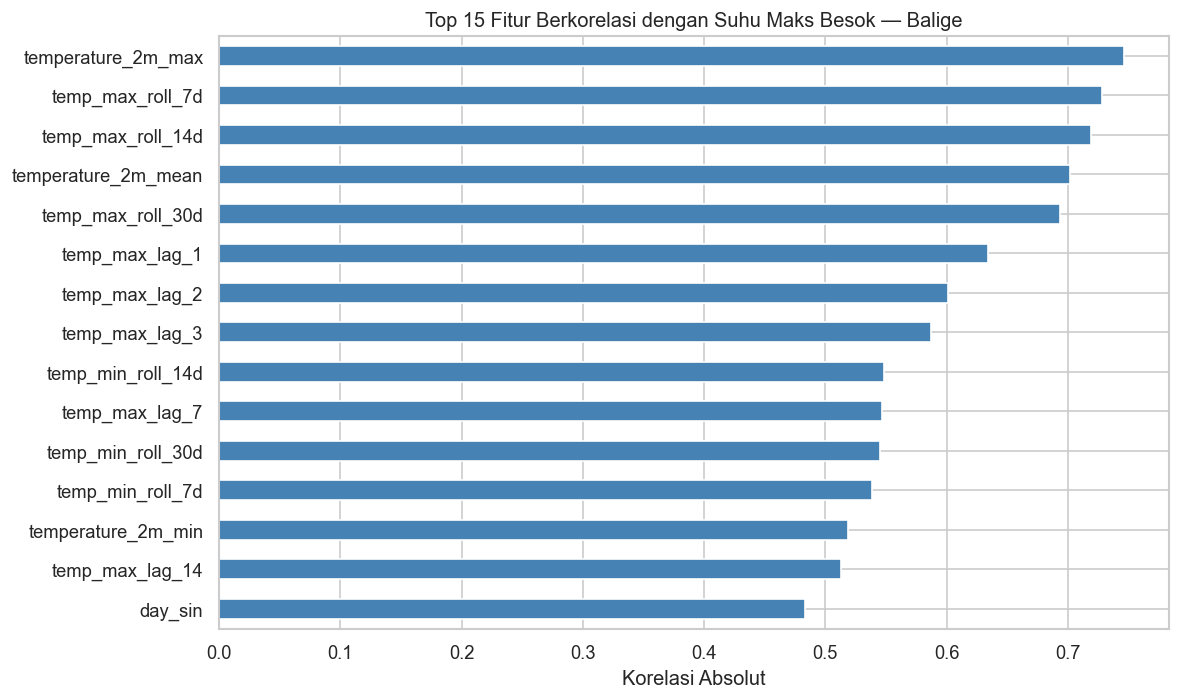


Top 10 fitur paling berkorelasi:
temperature_2m_max     0.746
temp_max_roll_7d       0.728
temp_max_roll_14d      0.719
temperature_2m_mean    0.702
temp_max_roll_30d      0.694
temp_max_lag_1         0.634
temp_max_lag_2         0.602
temp_max_lag_3         0.587
temp_min_roll_14d      0.549
temp_max_lag_7         0.547


In [9]:
# Buat target: suhu maks hari berikutnya (untuk Balige)
balige = df_clean[df_clean["location"] == "Balige (Tobasa)"].copy()
balige["target_temp_max"] = balige["temperature_2m_max"].shift(-1)
balige = balige.dropna(subset=["target_temp_max"])

# Pilih fitur numerik — hapus duplikat kolom dulu
balige = balige.loc[:, ~balige.columns.duplicated()]

num_features = [c for c in balige.columns if balige[c].dtype in ["float64","int64","int32"]
                and c not in ["lat","lon","weathercode","winddirection_10m_dominant","target_temp_max"]]

# Korelasi dengan target — pastikan hasilnya Series
corr_matrix = balige[num_features + ["target_temp_max"]].corr()
corr = corr_matrix["target_temp_max"].drop("target_temp_max")

# Pastikan corr adalah Series
print(f"Type corr: {type(corr)}")
print(f"Shape: {corr.shape}")

corr_sorted = corr.abs().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
corr_sorted.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Top 15 Fitur Berkorelasi dengan Suhu Maks Besok — Balige")
ax.set_xlabel("Korelasi Absolut")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../data/processed/06_feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 10 fitur paling berkorelasi:")
print(corr.abs().sort_values(ascending=False).head(10).round(3).to_string())